# Práctica 1. Primeros pasos con OpenCV

---

**Autores:** 
- Alba Ramos Quintana
- Néstor Jésus Henríquez Medina 

**Descripción:** Resolución de las tareas de la Práctica 1, incluyendo dibujo tablero de ajedrez y estilo Mondrian, seguimiento del píxel más claro/oscuro, efecto Pop-Art propio y efecto linterna interactivo.

---

Importaciones 

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

## Tarea 1: Tablero de Ajedrez
Creación de una imagen con la textura de tablero de ajedrez (800x800).
1. Resolución manual clásica (_sin IA_).
2. Resolución generada con IA.

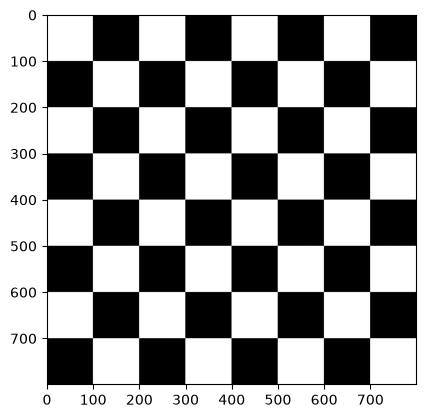

In [3]:
# SIN IA 
gris_img = np.zeros((800,800,1), dtype = np.uint8)

for i in range(0,800,100):
    for j in range(0,800,100):
        if (i//100 + j//100) % 2 == 0:
            gris_img[i:i+100,j:j+100,0] = 1

plt.imshow(gris_img, cmap='gray') 
plt.show()

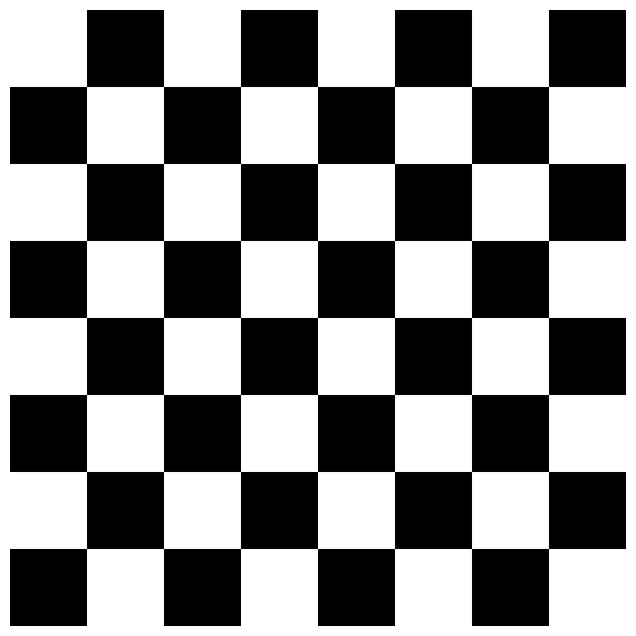

In [4]:
# CON IA
ancho = 800
alto = 800
num_casillas = 8

tablero = np.zeros((alto, ancho, 3), dtype=np.uint8)

ancho_casilla = ancho // num_casillas
alto_casilla = alto // num_casillas

for fila in range(num_casillas):
    for columna in range(num_casillas):
        color = (255, 255, 255) if (fila + columna) % 2 == 0 else (0, 0, 0)

        x1 = columna * ancho_casilla
        y1 = fila * alto_casilla
        x2 = (columna + 1) * ancho_casilla
        y2 = (fila + 1) * alto_casilla

        cv2.rectangle(tablero, (x1, y1), (x2, y2), color, thickness=-1)

cv2.imwrite("tablero_ajedrez.png", tablero)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(tablero, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Tarea 2: Creación de imagen estilo Mondrian con las funciones de dibujo de OpenCV.

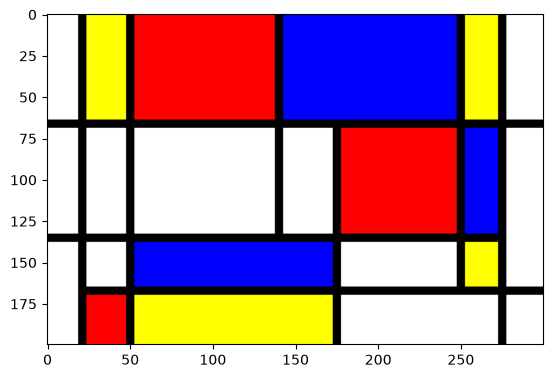

True

In [8]:
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

color_img[:,:,:] = 255 

negro = (0,0,0)
amarillo = (0,255,255)
azul = (0,0,255)
rojo = (255,0,0)
ancho = 300
alto = 200

cv2.rectangle(color_img,(int(ancho/14), 0),(int(ancho/6), int(alto/3)), amarillo, -1)
cv2.rectangle(color_img,(int(ancho/6), 0),(int((ancho/2)-10), int(alto/3)), azul, -1)
cv2.rectangle(color_img, (int((ancho/2)-10), 0), (int(ancho-50), int(alto/3)), rojo, -1)
cv2.rectangle(color_img,(int(ancho-50), 0),(int(ancho-25), int(alto/3)), amarillo, -1)

cv2.rectangle(color_img,(int((ancho/2)+25),int(alto/3)),(int(ancho-50), int((alto/2)+35)), azul, -1)
cv2.rectangle(color_img,(int(ancho-50),int(alto/3)),(int(ancho-25), int((alto/2)+35)), rojo, -1)

cv2.rectangle(color_img,(int(ancho/6),int((alto/2)+35)),(int((ancho/2)+25),int((alto+(alto/2)+35)/2)), rojo, -1)
cv2.rectangle(color_img,(int(ancho-50),int((alto/2)+35)),(int(ancho-25),int((alto+(alto/2)+35)/2)), amarillo, -1)

cv2.rectangle(color_img,(int(ancho/14),int((alto+(alto/2)+35)/2)),(int(ancho/6),int(alto)), azul, -1)
cv2.rectangle(color_img,(int(ancho/6),int((alto+(alto/2)+35)/2)),(int((ancho/2)+25),int(alto)), amarillo, -1)

cv2.line(color_img,(int(ancho/14),0),(int(ancho/14),int(alto)),negro,3)
cv2.line(color_img,(int(ancho/6),0),(int(ancho/6),int(alto)),negro,3)
cv2.line(color_img,(int((ancho/2)-10),0),(int((ancho/2)-10),int((alto/2)+35)),negro,3)
cv2.line(color_img,(int((ancho/2)+25),int(alto/3)),(int((ancho/2)+25),int(alto)),negro,3)
cv2.line(color_img,(int(ancho-50),0),(int(ancho-50),int((alto+(alto/2)+35)/2)),negro,3)
cv2.line(color_img,(int(ancho-25),0),(int(ancho-25),int(alto)),negro,3)

cv2.line(color_img,(0,int(alto/3)),(ancho,int(alto/3)),negro,3)
cv2.line(color_img,(0,int((alto/2)+35)),(int(ancho-25),int((alto/2)+35)),negro,3)
cv2.line(color_img,(int(ancho/14),int((alto+(alto/2)+35)/2)),(ancho,int((alto+(alto/2)+35)/2)),negro,3)

# Convertimos de BGR a RGB para que Matplotlib muestre los colores correctamente.
img_rgb = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) 
plt.show()  

cv2.imwrite('imagen_mondrian.jpg', color_img)

## Tarea 3: Píxeles Claro y Oscuro en Webcam
Pintar círculos en las posiciones del píxel más claro y oscuro.

- Funciona de manera fluida porque la resolución de la cámara estándar no es muy pesada para la función `cv2.minMaxLoc()`.

¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?

**Se ha decidido dibujar un círculo negro sobre el píxel más claro y un círculo blanco sobre el píxel más oscuro, garantizando así que siempre sean visibles por contraste, haciendo así que se vea con facilidad y se distinga bien.**

In [21]:
vid = cv2.VideoCapture(0)

while(True):      
    ret, frame = vid.read()

    if ret: 
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Búsqueda en Google: "cv2 mínimo y máximo"
        min_val, max_loc, min_loc, max_loc = cv2.minMaxLoc(frame_gray)

        cv2.circle(frame, min_loc, 10, (255,255,255), 2)
        cv2.circle(frame, max_loc, 10, (0,0,0), 2)
        
        cv2.imshow('Cam', frame)   
        
    if cv2.waitKey(20) == 27:
        break
  
vid.release()
cv2.destroyAllWindows()

## Tarea 4: Pop Art Propio (Efecto ASCII)
Conversión de la imagen de la cámara en tiempo real a una representación en caracyetes ASCII según el nivel de brillo por regiones.

In [33]:
vid = cv2.VideoCapture(0)
# Fuente: búsqueda en Google de "ascii array shadows"
char_ascii = ["@","%","#","*","+","=","-",":",".",","," "]

# Le damos la vuelta a la cadena para que la imagen se vea en positivo
char_ascii = char_ascii[::-1]

# Fuente para el caracter ascii
font = cv2.FONT_HERSHEY_PLAIN

image_width = 640
image_height = 480

# Tamaño aproximado de la zona de muestreo para cada carácter 
sample_width = 8
sample_height = 16

# Cantidad de columnas y filas de caracteres que caben en la imagen
num_columns = image_width // sample_width
num_rows = image_height // sample_height

while True:
    ret, frame = vid.read()

    if not ret:
        print("No se pudo leer la cámara")
        break

    # Flip horizontal para que se vea como un espejo. 
    # Fuente: https://www.geeksforgeeks.org/python/python-opencv-cv2-flip-method/
    frame = cv2.flip(frame,1)
    
    # Convertimos a escala de grises. 
    # Fuente: https://www.geeksforgeeks.org/python/python-grayscaling-of-images-using-opencv/
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Imagen con fondo negro donde se dibujarán los caracteres ascii
    ascii_frame = np.zeros(
        (image_height, image_width, 1),
        dtype=np.uint8
    )

    # Recorremos la imagen para ir dibujando los ascii
    for row in range(num_rows):
        for column in range(num_columns):
            # Coordenadas de la zona de muestreo de 16x16
            x1 = column * sample_width
            y1 = row * sample_height
            x2 = x1 + sample_width
            y2 = y1 + sample_height

            # Extraemos la zona a muestrear
            sample = gray[y1:y2, x1:x2]

            # Calculamos su brillo medio
            brightness = np.mean(sample)

            # Mapeamos brillo a carácter
            char_index = int(
                brightness * (len(char_ascii) - 1) / 255
            )
            character = char_ascii[char_index]

            # Dibujamos el carácter dentro de la zona de muestreo (sample)
            cv2.putText(
                ascii_frame,
                character,
                (x1, y1),
                font,
                0.85,
                (255, 255, 255),
                1
            )

    cv2.imshow("Webcam ASCII effect", ascii_frame)

    # Detenemos pulsando ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

## Extra: Efecto Linterna
Implementación interactiva de un "efecto linterna" que sigue la posición del puntero del ratón. En esta propuesta, en lugar de utilizar un simple fondo oscurecido o negro, se ha integrado el filtro visual.. 

De esta manera, el haz de luz revela y destaca la zona de la imagen con el efecto artístico aplicado, creando una interacción dinámica con el usuario sobre la captura de la cámara.

In [35]:
def mouse_events(event, x, y, flags, params):
    global px, py
    px = -1
    if event==cv2.EVENT_MOUSEMOVE:
        px = x
        py = y

vid = cv2.VideoCapture(0)

ncells = 10
off = int(ncells/2)

lanzado=0
radio=50
  
while(True):      
    ret, frame = vid.read()

    if ret:
        h, w, c = frame.shape

        if lanzado == 0:
            cv2.imshow('Cam', frame)
            cv2.setMouseCallback('Cam', mouse_events)
            lanzado = 1

        down_frame = cv2.resize(frame, (int(w/ncells),int(h/ncells)),cv2.INTER_NEAREST)
        h2, w2, c2 = down_frame.shape

        r = down_frame[:,:,0]
        g = down_frame[:,:,1]
        b = down_frame[:,:,2]

        gris_up_frame = np.zeros((h2*ncells,w2*ncells,1), dtype = np.uint8)

        for y in range(0,h2):
            for x in range(0,w2):
                rad = int ( (r[y,x] + g[y,x] + b[y,x])/(ncells*3*2))
                cv2.circle(gris_up_frame,(x*ncells+off, y*ncells + off), rad, (255,255,255), -1)

        gray_bgr = cv2.cvtColor(gris_up_frame, cv2.COLOR_GRAY2BGR)
        display_frame = gray_bgr.copy()

        # Fuente: https://www.youtube.com/watch?v=GqTGE1j3g_s&t=1s
        
        if px > -1 and py > -1:
            # Máscara para la "linterna"
            mask = np.zeros((h, w, 3), dtype=np.uint8)
            cv2.circle(mask, (px, py), radio, (255, 255, 255), -1)

            # Máscara invertida
            mask_inv = cv2.bitwise_not(mask)
            
            original = cv2.bitwise_and(frame, mask)
            filtro = cv2.bitwise_and(gray_bgr, mask_inv)

            display_frame = cv2.add(original, filtro)

        cv2.imshow('Cam', display_frame)
    
    if cv2.waitKey(20) == 27:
        break
  
vid.release()
cv2.destroyAllWindows()
  

C:\Users\User\AppData\Local\Temp\ipykernel_21264\2525536992.py:38: RuntimeWarning: overflow encountered in scalar add
  rad = int ( (r[y,x] + g[y,x] + b[y,x])/(ncells*3*2))


---